**Chapter 1 – The Machine Learning Landscape**

_This notebook contains the code examples in chapter 1. You'll also find the exercise solutions at the end of the notebook. The rest of this notebook is used to generate `lifesat.csv` from the original data sources, and some of this chapter's figures._

You're welcome to go through the code in this notebook if you want, but the real action starts in the next chapter.

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/01_the_machine_learning_landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/01_the_machine_learning_landscape.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.10 or above:

In [1]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [2]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Let's define the default font sizes, to plot pretty figures:

In [3]:
import matplotlib.pyplot as plt

plt.rc("font", size=12)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=12)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

# Code example 1-1

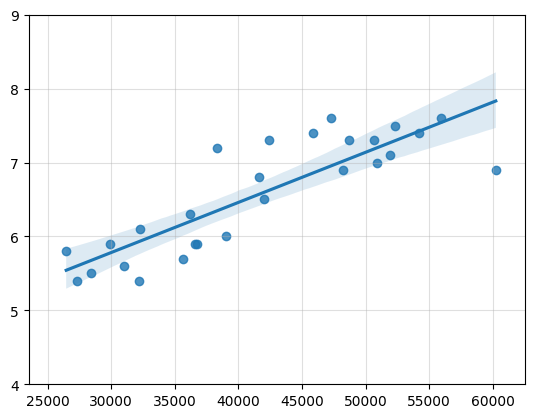

[[6.01610329]]


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import polars as pl
from sklearn.linear_model import LinearRegression

# Download and prepare the data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pl.read_csv(data_root + "lifesat/lifesat.csv")
X = lifesat.select("GDP per capita (USD)")
y = lifesat.select("Life satisfaction")

# Visualize the data

sns.regplot(data=lifesat, x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.grid(True, alpha=0.4)
plt.show()

# # Select a linear model
model = LinearRegression()

# # Train the model
model.fit(X, y)

# # Make a prediction for Puerto Rico
X_new = pl.DataFrame(
    {"GDP per capita (USD)": [33_442.8]}
)  # Puerto Rico' GDP per capita in 2020
print(model.predict(X_new))  # outputs [[6.01610329]]

Replacing the Linear Regression model with k-Nearest Neighbors (in this example, k = 3) regression in the previous code is as simple as replacing these two
lines:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

with these two:

```python
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)
```

In [5]:
# Select a 3-Nearest Neighbors regression model
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)

# Train the model
model.fit(X, y)

# Make a prediction for Puerto Rico
print(model.predict(X_new))  # outputs [[5.73333333]]


[[5.73333333]]


# Generating the data and figures — please skip

This is the code I used to generate the `lifesat.csv` dataset. You can safely skip this.

## Load and prepare Life satisfaction data

To create `lifesat.csv`, I downloaded the Better Life Index (BLI) data from [OECD's website](http://stats.oecd.org/index.aspx?DataSetCode=BLI) (to get the Life Satisfaction for each country), and World Bank GDP per capita data from [OurWorldInData.org](https://ourworldindata.org/grapher/gdp-per-capita-worldbank). The BLI data is in `datasets/lifesat/oecd_bli.csv` (data from 2020), and the GDP per capita data is in `datasets/lifesat/gdp_per_capita.csv` (data up to 2020).

If you want to grab the latest versions, please feel free to do so. However, there may be some changes (e.g., in the column names, or different countries missing data), so be prepared to have to tweak the code.

In [6]:
from pathlib import Path
import urllib.request

datapath = Path() / "datasets" / "lifesat"
datapath.mkdir(parents=True, exist_ok=True)

data_root = "https://github.com/ageron/data/raw/main/"
for filename in ("oecd_bli.csv", "gdp_per_capita.csv"):
    if not (datapath / filename).is_file():
        print("Downloading", filename)
        url = data_root + "lifesat/" + filename
        urllib.request.urlretrieve(url, datapath / filename)

In [7]:
oecd_bli = pl.read_csv(datapath / "oecd_bli.csv")
gdp_per_capita = pl.read_csv(datapath / "gdp_per_capita.csv")

Preprocess the GDP per capita data to keep only the year 2020:

In [8]:
# Prepare variables
gdp_year = 2020
gdppc_col = "GDP per capita (USD)"

# Filter and prepare the dataframe
gdp_per_capita = gdp_per_capita.filter(pl.col("Year") == gdp_year)
gdp_per_capita = gdp_per_capita.drop(["Code", "Year"])

# Rename columns correctly
gdp_per_capita = gdp_per_capita.rename(
    {
        "Entity": "Country",
        "GDP per capita, PPP (constant 2017 international $)": gdppc_col,
    }
)

# 6. Verify result
gdp_per_capita.head()

Country,GDP per capita (USD)
str,f64
"""Afghanistan""",1978.961579
"""Africa Eastern and Southern""",3387.59467
"""Africa Western and Central""",4003.158913
"""Albania""",13295.410885
"""Algeria""",10681.679297


Preprocess the OECD BLI data to keep only the `Life satisfaction` column:

In [9]:
oecd_bli = oecd_bli.filter(pl.col("INEQUALITY") == "TOT")

# 2. Use the Polars pivot method.
# Note the order of arguments: values, index, columns
oecd_bli = oecd_bli.pivot(values="Value", index="Country", on="Indicator")

# 3. View the result
oecd_bli.head()

Country,Labour market insecurity,Stakeholder engagement for developing regulations,Dwellings without basic facilities,Housing expenditure,Feeling safe walking alone at night,Rooms per person,Household net adjusted disposable income,Household net wealth,Employment rate,Long-term unemployment rate,Personal earnings,Quality of support network,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Voter turnout,Life expectancy,Self-reported health,Life satisfaction,Homicide rate,Employees working very long hours,Time devoted to leisure and personal care
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Australia""",5.4,2.7,null,20.0,63.5,null,32759.0,427064.0,73.0,1.31,49126.0,95.0,81.0,502.0,21.0,5.0,93.0,91.0,82.5,85.0,7.3,1.1,13.04,14.35
"""Austria""",3.5,1.3,0.9,21.0,80.6,1.6,33541.0,308325.0,72.0,1.84,50349.0,92.0,85.0,492.0,17.0,16.0,92.0,80.0,81.7,70.0,7.1,0.5,6.66,14.55
"""Belgium""",3.7,2.0,1.9,21.0,70.1,2.2,30364.0,386006.0,63.0,3.54,49675.0,91.0,77.0,503.0,19.3,15.0,84.0,89.0,81.5,74.0,6.9,1.0,4.75,15.7
"""Canada""",6.0,2.9,0.2,22.0,82.2,2.6,30854.0,423849.0,73.0,0.77,47622.0,93.0,91.0,523.0,17.3,7.0,91.0,68.0,81.9,88.0,7.4,1.3,3.69,14.56
"""Czech Republic""",3.1,1.6,0.7,24.0,72.3,1.4,21453.0,null,74.0,1.04,25372.0,91.0,94.0,491.0,17.9,20.0,87.0,61.0,79.1,60.0,6.7,0.5,5.65,null


Now let's merge the life satisfaction data and the GDP per capita data, keeping only the GDP per capita and Life satisfaction columns:

In [10]:
# 1. Re-define the column names for consistency
gdppc_col = "GDP per capita (USD)"
lifesat_col = "Life satisfaction"

# 2. Join the DataFrames (ensure they both have a 'Country' column)
full_country_stats = oecd_bli.join(gdp_per_capita, on="Country")

# 3. Sort by the GDP column
full_country_stats = full_country_stats.sort(gdppc_col)

# 4. Select only the columns you want
# IMPORTANT: Double-check that 'Life satisfaction' is the exact name in full_country_stats.columns
full_country_stats = full_country_stats.select(["Country", gdppc_col, lifesat_col])

# 5. View the result
full_country_stats.head()

Country,GDP per capita (USD),Life satisfaction
str,f64,f64
"""South Africa""",11466.189672,4.7
"""Colombia""",13441.492952,6.3
"""Brazil""",14063.982505,6.4
"""Mexico""",17887.750736,6.5
"""Chile""",23324.524751,6.5


To illustrate the risk of overfitting, I use only part of the data in most figures (all countries with a GDP per capita between `min_gdp` and `max_gdp`). Later in the chapter I reveal the missing countries, and show that they don't follow the same linear trend at all.

In [11]:
min_gdp = 23_500
max_gdp = 62_500

# Use .filter() and pl.col() instead of square brackets with boolean masks
country_stats = full_country_stats.filter(
    (pl.col(gdppc_col) >= min_gdp) & (pl.col(gdppc_col) <= max_gdp)
)

country_stats.head()

Country,GDP per capita (USD),Life satisfaction
str,f64,f64
"""Russia""",26456.387938,5.8
"""Greece""",27287.083401,5.4
"""Turkey""",28384.987785,5.5
"""Latvia""",29932.49391,5.9
"""Hungary""",31007.768407,5.6


In [12]:
country_stats.write_csv(datapath / "lifesat.csv")
full_country_stats.write_csv(datapath / "lifesat_full.csv")

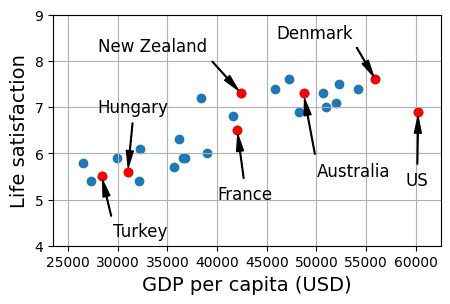

In [13]:
# Configuration
GDP_YEAR = 2020
MIN_GDP = 23_500
MAX_GDP = 62_500
MIN_LIFE_SAT = 4
MAX_LIFE_SAT = 9

# 1. Plotting
plt.figure(figsize=(5, 3))
plt.scatter(country_stats[gdppc_col], country_stats[lifesat_col])
plt.grid(True)
plt.xlabel(gdppc_col)
plt.ylabel(lifesat_col)

# 2. Define annotations
position_text = {
    "Turkey": (29_500, 4.2),
    "Hungary": (28_000, 6.9),
    "France": (40_000, 5),
    "New Zealand": (28_000, 8.2),
    "Australia": (50_000, 5.5),
    "United States": (59_000, 5.3),
    "Denmark": (46_000, 8.5),
}

# 3. Annotation loop
for country, pos_text in position_text.items():
    row = country_stats.filter(pl.col("Country") == country)

    if len(row) > 0:
        # Accessing data in Polars
        pos_data_x = row[gdppc_col].item()
        pos_data_y = row[lifesat_col].item()

        display_name = "US" if country == "United States" else country

        plt.annotate(
            display_name,
            xy=(pos_data_x, pos_data_y),
            xytext=pos_text,
            fontsize=12,
            arrowprops=dict(facecolor="black", width=0.5, shrink=0.08, headwidth=5),
        )
        plt.plot(pos_data_x, pos_data_y, "ro")

# Use the uppercase constants you defined at the top of the cell
plt.axis([MIN_GDP, MAX_GDP, MIN_LIFE_SAT, MAX_LIFE_SAT])
plt.show()

In [14]:
# 1. Get the list of countries from the dictionary keys
countries_to_highlight = list(position_text.keys())

# 2. Filter for those countries using .is_in()
highlighted_countries = country_stats.filter(
    pl.col("Country").is_in(countries_to_highlight)
)

# 3. Select the columns and sort them
result = highlighted_countries.select([gdppc_col, lifesat_col]).sort(gdppc_col)

# 4. View result
result

GDP per capita (USD),Life satisfaction
f64,f64
28384.987785,5.5
31007.768407,5.6
42025.617373,6.5
42404.393738,7.3
48697.837028,7.3
55938.212809,7.6
60235.728492,6.9


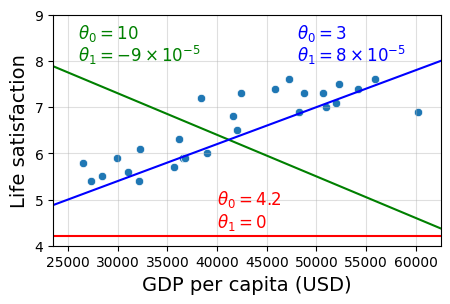

In [15]:
# 1. Use Seaborn for the scatter plot
plt.figure(figsize=(5, 3))
sns.scatterplot(data=country_stats, x=gdppc_col, y=lifesat_col)
plt.grid(alpha=0.4)

# 2. Define X range using your defined constants
X = np.linspace(MIN_GDP, MAX_GDP, 1000)

# 3. Plot the lines (These remain Matplotlib calls)
w1, w2 = 4.2, 0
plt.plot(X, w1 + w2 * 1e-5 * X, "r")
plt.text(40_000, 4.9, rf"$\theta_0 = {w1}$", color="r")
plt.text(40_000, 4.4, rf"$\theta_1 = {w2}$", color="r")

w1, w2 = 10, -9
plt.plot(X, w1 + w2 * 1e-5 * X, "g")
plt.text(26_000, 8.5, rf"$\theta_0 = {w1}$", color="g")
plt.text(26_000, 8.0, rf"$\theta_1 = {w2} \times 10^{{-5}}$", color="g")

w1, w2 = 3, 8
plt.plot(X, w1 + w2 * 1e-5 * X, "b")
plt.text(48_000, 8.5, rf"$\theta_0 = {w1}$", color="b")
plt.text(48_000, 8.0, rf"$\theta_1 = {w2} \times 10^{{-5}}$", color="b")

# 4. Set axis limits
plt.axis([MIN_GDP, MAX_GDP, MIN_LIFE_SAT, MAX_LIFE_SAT])

plt.show()

In [16]:
from sklearn import linear_model

X_sample = country_stats.select([gdppc_col])
y_sample = country_stats.select([lifesat_col])

# 2. Train the model
lin1 = linear_model.LinearRegression()
lin1.fit(X_sample, y_sample)

# 3. Extract intercept and coefficient
# Note: Since your X_sample is 2D and y_sample is 2D,
# lin1.intercept_ and lin1.coef_ will be numpy arrays.
t0 = lin1.intercept_[0]
t1 = lin1.coef_[0][0]

print(f"θ0={t0:.2f}, θ1={t1:.2e}")

θ0=3.75, θ1=6.78e-05


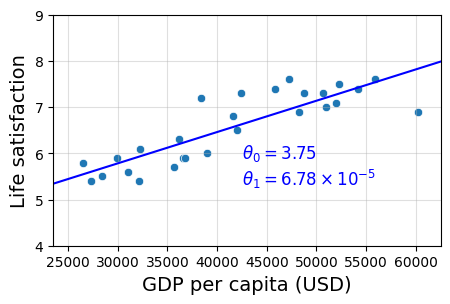

In [17]:
# 1. Use Seaborn for the scatter plot
plt.figure(figsize=(5, 3))
sns.scatterplot(data=country_stats, x=gdppc_col, y=lifesat_col)
plt.grid(alpha=0.4)
plt.xlabel(gdppc_col)
plt.ylabel(lifesat_col)

# 2. Define the X range using your defined constants
X = np.linspace(MIN_GDP, MAX_GDP, 1000)

# 3. Plot the Linear Regression line
# Use the t0 and t1 calculated from the sklearn model
plt.plot(X, t0 + t1 * X, "b")

# 4. Add the labels (using uppercase constants for coordinates)
# We use max_gdp/min_life_sat equivalent logic
plt.text(MAX_GDP - 20_000, MIN_LIFE_SAT + 1.9, rf"$\theta_0 = {t0:.2f}$", color="b")
plt.text(
    MAX_GDP - 20_000,
    MIN_LIFE_SAT + 1.3,
    rf"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$",
    color="b",
)

# 5. Set axis limits using constants
plt.axis([MIN_GDP, MAX_GDP, MIN_LIFE_SAT, MAX_LIFE_SAT])

plt.show()

In [18]:
# 1. Filter the DataFrame to find the row where "Country" is "Puerto Rico"
# 2. Select the GDP column
# 3. Use .item() to extract the single value
puerto_rico_gdp_per_capita = (
    gdp_per_capita.filter(pl.col("Country") == "Puerto Rico").select(gdppc_col).item()
)

puerto_rico_gdp_per_capita

33442.8315702748

In [19]:
# 1. Create a 1-row Polars DataFrame with the correct column name
X_new = pl.DataFrame({gdppc_col: [puerto_rico_gdp_per_capita]})

# 2. Predict using this DataFrame (this keeps the feature name)
prediction = lin1.predict(X_new)

# 3. Extract the value
puerto_rico_predicted_life_satisfaction = prediction[0, 0]

print(
    f"Predicted Life Satisfaction for Puerto Rico: {puerto_rico_predicted_life_satisfaction:.2f}"
)

Predicted Life Satisfaction for Puerto Rico: 6.02


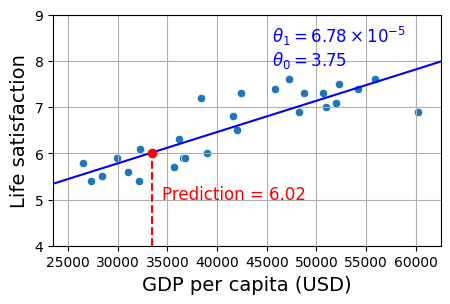

In [20]:
# 1. Plot the scatter plot using Seaborn
plt.figure(figsize=(5, 3))
sns.scatterplot(data=country_stats, x=gdppc_col, y=lifesat_col)
plt.grid(True)
plt.xlabel(gdppc_col)
plt.ylabel(lifesat_col)

# 2. Plot the Linear Regression line
X = np.linspace(MIN_GDP, MAX_GDP, 1000)
plt.plot(X, t0 + t1 * X, "b")

# 3. Add regression coefficients text
plt.text(MIN_GDP + 22_000, MAX_LIFE_SAT - 1.1, rf"$\theta_0 = {t0:.2f}$", color="b")
plt.text(
    MIN_GDP + 22_000,
    MAX_LIFE_SAT - 0.6,
    rf"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$",
    color="b",
)

# 4. Plot the prediction line for Puerto Rico
plt.plot(
    [puerto_rico_gdp_per_capita, puerto_rico_gdp_per_capita],
    [MIN_LIFE_SAT, puerto_rico_predicted_life_satisfaction],
    "r--",
)

# 5. Add prediction text and point
plt.text(
    puerto_rico_gdp_per_capita + 1000,
    5.0,
    rf"Prediction = {puerto_rico_predicted_life_satisfaction:.2f}",
    color="r",
)
plt.plot(puerto_rico_gdp_per_capita, puerto_rico_predicted_life_satisfaction, "ro")

# 6. Set axis limits using uppercase constants
plt.axis([MIN_GDP, MAX_GDP, MIN_LIFE_SAT, MAX_LIFE_SAT])

plt.show()

In [21]:
# Remember to use the uppercase constants you defined earlier
missing_data = full_country_stats.filter(
    (pl.col(gdppc_col) < MIN_GDP) | (pl.col(gdppc_col) > MAX_GDP)
)

missing_data

Country,GDP per capita (USD),Life satisfaction
str,f64,f64
"""South Africa""",11466.189672,4.7
"""Colombia""",13441.492952,6.3
"""Brazil""",14063.982505,6.4
"""Mexico""",17887.750736,6.5
"""Chile""",23324.524751,6.5
"""Norway""",63585.903514,7.6
"""Switzerland""",68393.306004,7.5
"""Ireland""",89688.956958,7.0
"""Luxembourg""",110261.157353,6.9


In [22]:
position_text_missing_countries = {
    "South Africa": (20_000, 4.2),
    "Colombia": (6_000, 8.2),
    "Brazil": (18_000, 7.8),
    "Mexico": (24_000, 7.4),
    "Chile": (30_000, 7.0),
    "Norway": (51_000, 6.2),
    "Switzerland": (62_000, 5.7),
    "Ireland": (81_000, 5.2),
    "Luxembourg": (92_000, 4.7),
}

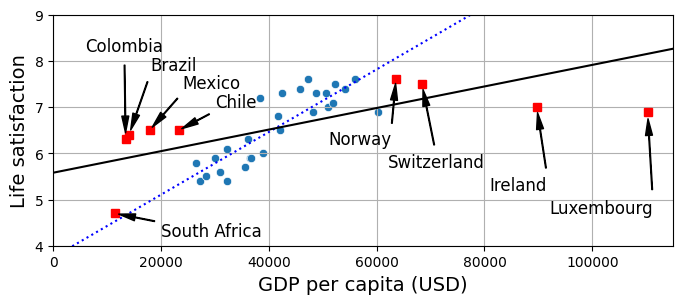

In [23]:
# 1. Plot the full dataset (Seaborn/Matplotlib instead of .plot())
plt.figure(figsize=(8, 3))
sns.scatterplot(data=full_country_stats, x=gdppc_col, y=lifesat_col)
plt.grid(True)

# 2. Annotation loop (Polars filter instead of .loc)
for country, pos_text in position_text_missing_countries.items():
    # Filter the row for the specific country
    row = missing_data.filter(pl.col("Country") == country)

    if len(row) > 0:
        pos_data_x = row[gdppc_col].item()
        pos_data_y = row[lifesat_col].item()

        plt.annotate(
            country,
            xy=(pos_data_x, pos_data_y),
            xytext=pos_text,
            fontsize=12,
            arrowprops=dict(facecolor="black", width=0.5, shrink=0.08, headwidth=5),
        )
        plt.plot(pos_data_x, pos_data_y, "rs")

# 3. Plot the original (restricted) linear regression line
X = np.linspace(0, 115_000, 1000)
plt.plot(X, t0 + t1 * X, "b:")

# 4. Train a new model on the FULL dataset
lin_reg_full = linear_model.LinearRegression()

# In Polars, select the column - sklearn accepts Polars DataFrames/Series directly
Xfull = full_country_stats.select([gdppc_col])
yfull = full_country_stats.select([lifesat_col])

lin_reg_full.fit(Xfull, yfull)

# 5. Get new coefficients
t0full = lin_reg_full.intercept_.item()
t1full = lin_reg_full.coef_.item()

# Plot the new full regression line
plt.plot(X, t0full + t1full * X, "k")

# 6. Set axis limits using constants
plt.axis([0, 115_000, MIN_LIFE_SAT, MAX_LIFE_SAT])

plt.show()

/home/palash/Downloads/handson-mlp/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


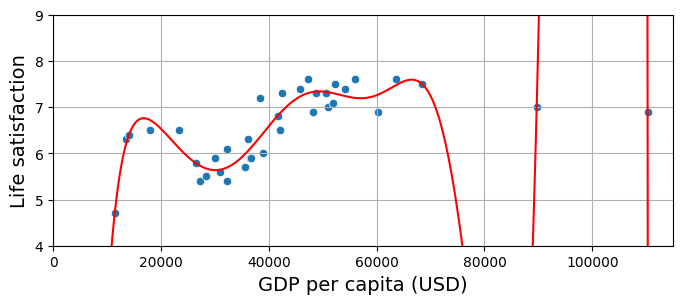

In [24]:
from sklearn import preprocessing
from sklearn import pipeline

# 1. Use Seaborn/Matplotlib for the scatter plot
plt.figure(figsize=(8, 3))
sns.scatterplot(data=full_country_stats, x=gdppc_col, y=lifesat_col)
plt.grid(True)
plt.xlabel(gdppc_col)
plt.ylabel(lifesat_col)

# 2. Define the pipeline
poly = preprocessing.PolynomialFeatures(degree=10, include_bias=False)
scaler = preprocessing.StandardScaler()
lin_reg2 = linear_model.LinearRegression()

pipeline_reg = pipeline.Pipeline([("poly", poly), ("scal", scaler), ("lin", lin_reg2)])

# 3. Fit the pipeline using the data prepared previously (Xfull, yfull)
pipeline_reg.fit(Xfull, yfull)

# 4. Predict the curve
# X was defined in the previous block as np.linspace(0, 115_000, 1000)
# We need to reshape X to be 2D for scikit-learn
curve = pipeline_reg.predict(X[:, np.newaxis])

# 5. Plot the polynomial curve
plt.plot(X, curve, color="r", label="Polynomial Degree 10")

# 6. Set axis limits using your uppercase constants
plt.axis([0, 115_000, MIN_LIFE_SAT, MAX_LIFE_SAT])

plt.show()

In [25]:
w_countries_df = full_country_stats.filter(
    pl.col("Country").str.to_uppercase().str.contains("W")
)

# 2. Select only the life satisfaction column
result = w_countries_df.select([lifesat_col])

result

Life satisfaction
f64
7.3
7.3
7.6
7.5


In [26]:
all_w_countries = gdp_per_capita.filter(
    pl.col("Country").str.to_uppercase().str.contains("W")
)

# 2. Sort the result by the GDP column
result = all_w_countries.sort(gdppc_col)

# 3. View the result
result

Country,GDP per capita (USD)
str,f64
"""Malawi""",1486.778248
"""Rwanda""",2098.710362
"""Zimbabwe""",2744.690758
"""Africa Western and Central""",4003.158913
"""Papua New Guinea""",4101.218882
…,…
"""World""",16194.04031
"""New Zealand""",42404.393738
"""Sweden""",50683.32351


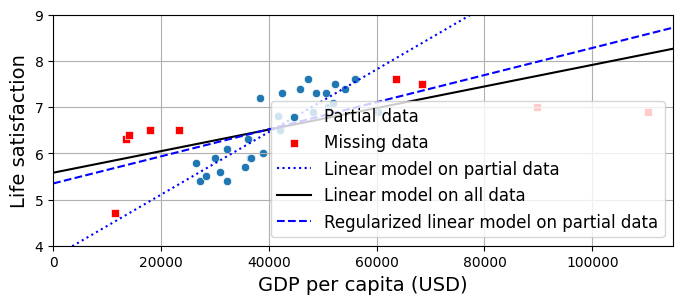

In [27]:
# 1. Plotting: Use Seaborn for both sets of data
plt.figure(figsize=(8, 3))
sns.scatterplot(data=country_stats, x=gdppc_col, y=lifesat_col, label="Partial data")
sns.scatterplot(
    data=missing_data,
    x=gdppc_col,
    y=lifesat_col,
    marker="s",
    color="r",
    label="Missing data",
)
plt.grid(True)
plt.xlabel(gdppc_col)
plt.ylabel(lifesat_col)

# 2. Linear models
X = np.linspace(0, 115_000, 1000)
plt.plot(X, t0 + t1 * X, "b:", label="Linear model on partial data")
plt.plot(X, t0full + t1full * X, "k-", label="Linear model on all data")

# 3. Ridge Regression: sklearn accepts Polars DataFrames/Series directly
ridge = linear_model.Ridge(alpha=10**9.5)
X_sample = country_stats.select([gdppc_col])
y_sample = country_stats.select([lifesat_col])
ridge.fit(X_sample, y_sample)

# Safely extract coefficients
t0ridge = ridge.intercept_.item()
t1ridge = ridge.coef_.item()

plt.plot(
    X, t0ridge + t1ridge * X, "b--", label="Regularized linear model on partial data"
)
plt.legend(loc="lower right")

# 4. Axis limits using uppercase constants
plt.axis([0, 115_000, MIN_LIFE_SAT, MAX_LIFE_SAT])

plt.show()

# Exercise Solutions

1. Machine Learning is about building systems that can learn from data. Learning means getting better at some task, given some performance measure.
2. Machine Learning is great for complex problems for which we have no algorithmic solution, to replace long lists of hand-tuned rules, to build systems that adapt to fluctuating environments, and finally to help humans learn (e.g., data mining).
3. A labeled training set is a training set that contains the desired solution (a.k.a. a label) for each instance.
4. The two most common supervised tasks are regression and classification.
5. Common unsupervised tasks include clustering, visualization, dimensionality reduction, and association rule learning.
6. Reinforcement Learning is likely to perform best if we want a robot to learn to walk in various unknown terrains, since this is typically the type of problem that Reinforcement Learning tackles. It might be possible to express the problem as a supervised or semi-supervised learning problem, but it would be less natural.
7. If you don't know how to define the groups, then you can use a clustering algorithm (unsupervised learning) to segment your customers into clusters of similar customers. However, if you know what groups you would like to have, then you can feed many examples of each group to a classification algorithm (supervised learning), and it will classify all your customers into these groups.
8. Spam detection is a typical supervised learning problem: the algorithm is fed many emails along with their labels (spam or not spam).
9. An online learning system can learn incrementally, as opposed to a batch learning system. This makes it capable of adapting rapidly to both changing data and autonomous systems, and of training on very large quantities of data.
10. Out-of-core algorithms can handle vast quantities of data that cannot fit in a computer's main memory. An out-of-core learning algorithm chops the data into mini-batches and uses online learning techniques to learn from these mini-batches.
11. An instance-based learning system learns the training data by heart; then, when given a new instance, it uses a similarity measure to find the most similar learned instances and uses them to make predictions.
12. A model has one or more model parameters that determine what it will predict given a new instance (e.g., the slope of a linear model). A learning algorithm tries to find optimal values for these parameters such that the model generalizes well to new instances. A hyperparameter is a parameter of the learning algorithm itself, not of the model (e.g., the amount of regularization to apply).
13. Model-based learning algorithms search for an optimal value for the model parameters such that the model will generalize well to new instances. We usually train such systems by minimizing a cost function that measures how bad the system is at making predictions on the training data, plus a penalty for model complexity if the model is regularized. To make predictions, we feed the new instance's features into the model's prediction function, using the parameter values found by the learning algorithm.
14. Some of the main challenges in Machine Learning are the lack of data, poor data quality, nonrepresentative data, uninformative features, excessively simple models that underfit the training data, and excessively complex models that overfit the data.
15. If a model performs great on the training data but generalizes poorly to new instances, the model is likely overfitting the training data (or we got extremely lucky on the training data). Possible solutions to overfitting are getting more data, simplifying the model (selecting a simpler algorithm, reducing the number of parameters or features used, or regularizing the model), or reducing the noise in the training data.
16. A test set is used to estimate the generalization error that a model will make on new instances, before the model is launched in production.
17. A validation set is used to compare models. It makes it possible to select the best model and tune the hyperparameters.
18. The train-dev set is used when there is a risk of mismatch between the training data and the data used in the validation and test datasets (which should always be as close as possible to the data used once the model is in production). The train-dev set is a part of the training set that's held out (the model is not trained on it). The model is trained on the rest of the training set, and evaluated on both the train-dev set and the validation set. If the model performs well on the training set but not on the train-dev set, then the model is likely overfitting the training set. If it performs well on both the training set and the train-dev set, but not on the validation set, then there is probably a significant data mismatch between the training data and the validation + test data, and you should try to improve the training data to make it look more like the validation + test data.
19. If you tune hyperparameters using the test set, you risk overfitting the test set, and the generalization error you measure will be optimistic (you may launch a model that performs worse than you expect).